<a href="https://colab.research.google.com/github/abdullahnaeem151015-lgtm/Machine-learning-content-refresh-study/blob/main/Copy_of_capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

# **Identifying Content Refresh Opportunities Using low CTR and high impressions threshold**

# **Abstract**

This study investigates whether a specific threshold for CTR and impressions can be used to identify high-potential content refresh opportunities. Using the 90th percentile of impressions among observations with at least one impression, with 100 impressions as a fallback, and the 25th percentile of positive CTR values, with 0.0001 as a fallback when needed, we establish a rule-based baseline and then evaluate supervised machine-learning models using multiple content-performance characteristics, target-leakage checks, and a time-aware train/test split. Model performance is assessed using classification metrics, permutation importance, and error analysis, with the experiments conducted on a 30% stratified sample of the dataset. Random Forest achieved the strongest ROC-AUC, Logistic Regression achieved the strongest recall, and Decision Tree slightly led several threshold-dependent metrics. The final scoring framework converted the identified signals into a ranked refresh-review queue with priority scores, reason codes, and recommended actions, providing a practical decision-support system rather than treating every flagged page as a guaranteed refresh requirement.


# **Introduction / Problem Statement**

Content pages can receive high search visibility while attracting fewer clicks than expected. In practice, this creates a prioritization problem: a large content portfolio may contain many pages with weak CTR, but reviewing every low-CTR page is neither efficient nor useful. A page with low CTR may simply have low demand, a different ranking position, a niche audience, or temporary performance changes, so low CTR alone is not enough to conclude that the page requires a refresh.

The specific challenge in this study is therefore to identify high-visibility content whose CTR is comparatively weak and which deserves review first. The initial approach uses a transparent rule based on high impressions and low CTR: impressions above the 90th percentile of positive-impression observations with 100 impressions as a fallback and CTR below the 25th percentile of positive CTR values with 0.0001 as a fallback. This provides a practical definition of a refresh candidate, but it remains a rule-based proxy rather than confirmed evidence that every flagged page needs to be updated.

A later validation also tests whether making the CTR threshold aware of ranking-position tiers changes refresh decisions. This is important because CTR performance can vary across different ranking positions, meaning that the definition of underperformance itself may affect which observations are selected for review.

This matters because an inaccurate prioritization system can create unnecessary review work or cause genuine opportunities to be missed. A useful system should therefore help narrow a large set of observations into a manageable review queue while remaining clear that the recommendation is decision support rather than an automatic instruction to refresh.

To address this problem, this study first establishes the high-impression/low-CTR rule and then evaluates Logistic Regression, Decision Tree, and Random Forest models using additional content-performance characteristics under a time-aware validation design. The analysis also checks for target leakage, examines permutation importance and prediction errors, compares the original rule with a position-aware alternative, and converts the resulting signals into a ranked action queue.

The remainder of the paper describes the dataset and exclusions, explains the target definition and modeling methodology, reports model and baseline results, discusses limitations, presents the ranked recommendations, and provides links to the notebooks and repository for reproducibility


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

# **Data**

The data used in this study came from the **FlyRank / internship warehouse dataset**, using the **`fact_content_daily_performance_sample.parquet`** table. The source table contains daily performance observations for pseudonymized content of pseudonymized clients rather than verified page-level refresh outcomes.

The analysis covers the period from **June 1 to June 30, 2026**. For time-aware model validation, observations from **June 1–24, 2026** were used for training, while observations from **June 25–30, 2026** were held out for testing.

To make the modeling experiment computationally manageable while preserving the target distribution, a **30% stratified sample** of the available observations was used. This produced approximately **3.5 million observations** for the model experiment.

The target-defining variables — including **`gsc_impressions`**, **`gsc_clicks`**, and calculated CTR — were not included as model predictors because they directly contribute to constructing the refresh label and could therefore introduce target leakage.

Client and content identifiers, together with data-availability flags such as **`client_has_gsc`**, **`client_has_ga4`**, **`gsc_data_available`**, and **`ga4_data_available`**, were also excluded as model predictors. Rows missing any of the selected modeling features were removed before training and evaluation.

The dataset is pseudonymized, and no client names, private URLs, or private search queries are presented in this paper.


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

# **Methodology**

**Assumption**

The main assumption of this research is that content receiving relatively high impressions but comparatively low CTR may represent a reasonable candidate for the content team to review.

This does not prove that the content definitely requires a refresh. It only identifies observations that may deserve further investigation before the content team decides whether an update is necessary.

**Features**

The features used to train the machine-learning models were:
-`gsc_avg_position`
- `ga4_pageviews`
- `ga4_sessions`
- `ga4_users`
- `ga4_engaged_sessions`
- `ga4_total_engagement_sec`
- `sessions_organic`
- `sessions_direct`
- `sessions_referral`
- `sessions_social`
- `sessions_paid`
- `sessions_ai`
- `ai_chatgpt`
- `ai_perplexity`
- `ai_gemini`
- `ai_copilot`
- `ai_claude`
- `ai_meta`
- `ai_other`
- `scroll_events`

The target-defining CTR, clicks, and impression variables were intentionally excluded from this feature set.


**Label Definition**

Two thresholds were used to construct the original refresh-candidate label.

The high-impressions threshold was calculated as the 90th percentile among observations with positive impressions. If no valid positive-impression observations existed, 100 impressions was used as the fallback threshold.

The low-CTR threshold was calculated as the 25th percentile among observations with a positive CTR. If the resulting percentile was zero, or if no positive CTR observations existed, 0.0001 was used as the fallback threshold.

An observation was labeled as a refresh candidate (1) when both conditions were satisfied:

- impressions were above the high-impressions threshold; and
- CTR was below the low-CTR threshold.

All remaining observations were labeled as non-refresh candidates (0).

The target should therefore be understood as a practical proxy for review priority, rather than independently verified ground truth that a page definitely requires a refresh.




**Baseline Rule**

The Week-4 baseline uses the same high-impression and low-CTR conditions that define the target label.
The baseline rule assigns a label of 1 to observations that meet the high-impression, low-CTR conditions and are therefore treated as refresh-review candidates. Observations that do not meet these conditions are assigned a label of 0 and are treated as non-candidates under the rule.
After defining the baseline refresh-candidate rule, a ranked review queue was created to prioritize content rather than treating all observations equally. Impressions and CTR were first scaled to a common 0–1 range. Because lower CTR represents a greater potential opportunity in this task, the scaled CTR was inverted using 1 - scaled CTR. The final priority score was then calculated by multiplying scaled impressions by the low-CTR opportunity score, so observations with both relatively high visibility and relatively low CTR received higher scores. Content that also met the original high-impression and low-CTR baseline thresholds was assigned the reason code REFRESH_POTENTIAL_CTR_GAIN. The observations were then ranked from highest to lowest score to produce the final review queue.
Because the rule itself defines the target, applying that same rule to the target produces perfect classification scores. Therefore, the baseline's scores of 1.000 do not represent independent predictive performance. They represent agreement with the rule used to construct the label.

The machine-learning models are therefore evaluated as attempts to learn patterns associated with this proxy target from other content-performance characteristics, rather than as models that can meaningfully be claimed to outperform a mathematically identical baseline rule.

**Notebook Link**: [**View Notebook**](https://github.com/abdullahnaeem151015-lgtm/Machine-learning-content-refresh-study/blob/main/work/notebooks/Copy_of_w04_baseline_score%20(1).ipynb)



**Models**

Three supervised classification models were evaluated:

1. Logistic Regression
2. Decision Tree
3. Random Forest

These models were selected to compare a simpler linear classifier with tree-based approaches capable of learning more complex relationships between the selected features and the refresh-candidate label.

The errors in the prediction of the models were analyzed later by error analysis technique to understand where the model is mostly giving wrong predictions by check False positives and False Negatives and permutation importance was done to check which feature is most important for our model’s predictions by measuring how much model’s performance drops by randomly shuffling the features.

**Notebook Link**: [**View Notebook**](https://github.com/abdullahnaeem151015-lgtm/Machine-learning-content-refresh-study/blob/main/work/notebooks/w05_model.ipynb)


**Validation Design**

A time-aware validation strategy was used instead of a random train/test split.

Observations were ordered by report_date, with approximately the first 80% of unique dates used for training and the remaining 20% used for testing.

The resulting windows were:

- Training: June 1–24, 2026
- Testing: June 25–30, 2026

This design evaluates whether patterns learned from earlier observations can generalize to later observations and better reflects how the model could be used on future performance data.

Using this validation design the comparison was made between the original rule and CTR threshold aware of position tiers to check whether position tier aware CTR threshold rule can change the refresh decisions or not.

Feature scaling was fitted only on the training data and then applied to the test data.

Because the refresh-candidate class was imbalanced, **SMOTE** was applied only to the training set. The held-out test data was not oversampled or modified by SMOTE.


**Leakage Checks**

Several leakage checks were performed to make sure that the model was not accidentally given information that directly revealed the target.

These checks included:

- verifying that target-defining columns were not present in the final model features;
- confirming that the maximum training date occurred before the minimum testing date;
- verifying that training and testing dates did not overlap;
- fitting preprocessing steps such as scaling using the training data only; and
- applying SMOTE only to the training set.

These checks reduce the risk of overly optimistic performance caused by information leaking from the target or future observations into model training.




## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

# **Results**

Applying the baseline thresholds identified a subset of observations with both relatively high impressions and low CTR. Figure 1 shows how these refresh-review candidates are distributed relative to the two threshold boundaries


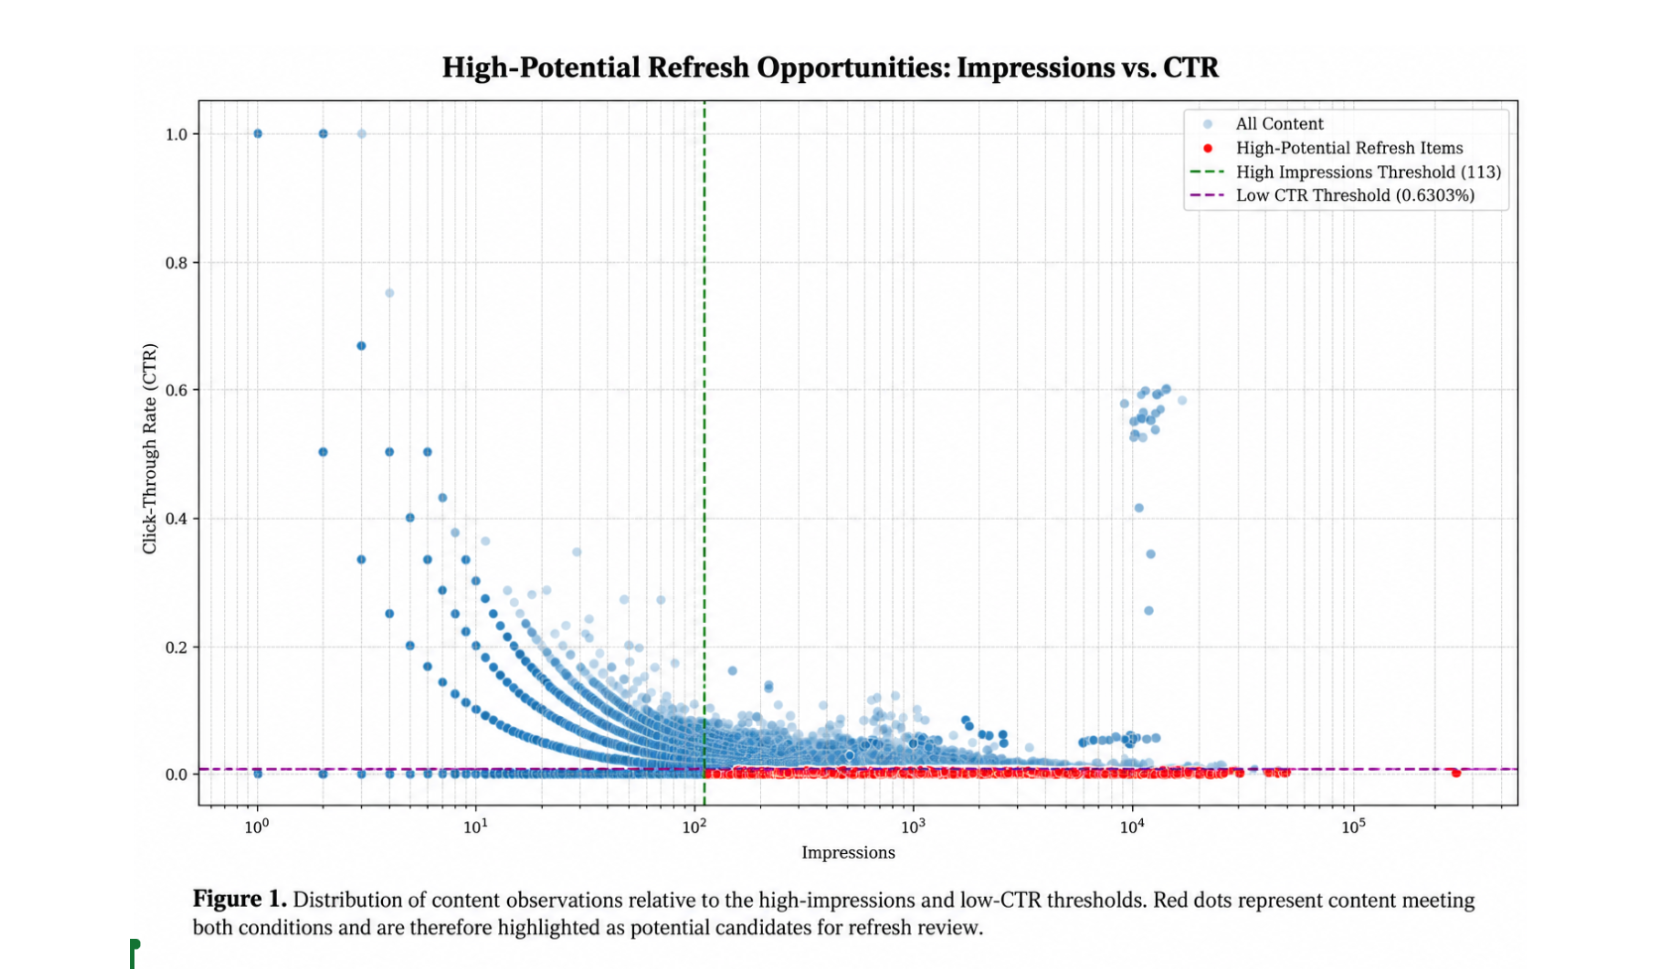

The models were evaluated on the same held-out time-based test period using Accuracy, Precision for the refresh class, Recall for the refresh class, F1 score(class 1 and weighted), and ROC-AUC.
The above table and graph shows the performance of models according to different metrics with bolded numbers showing the best performing metrics across different models. The week 4 rule reference performance is also shown at the bottom of table according to different metrics. The perfect performance of week 4 rule reference is expected as it is used to define the target label definition rather than independent predictive performance.


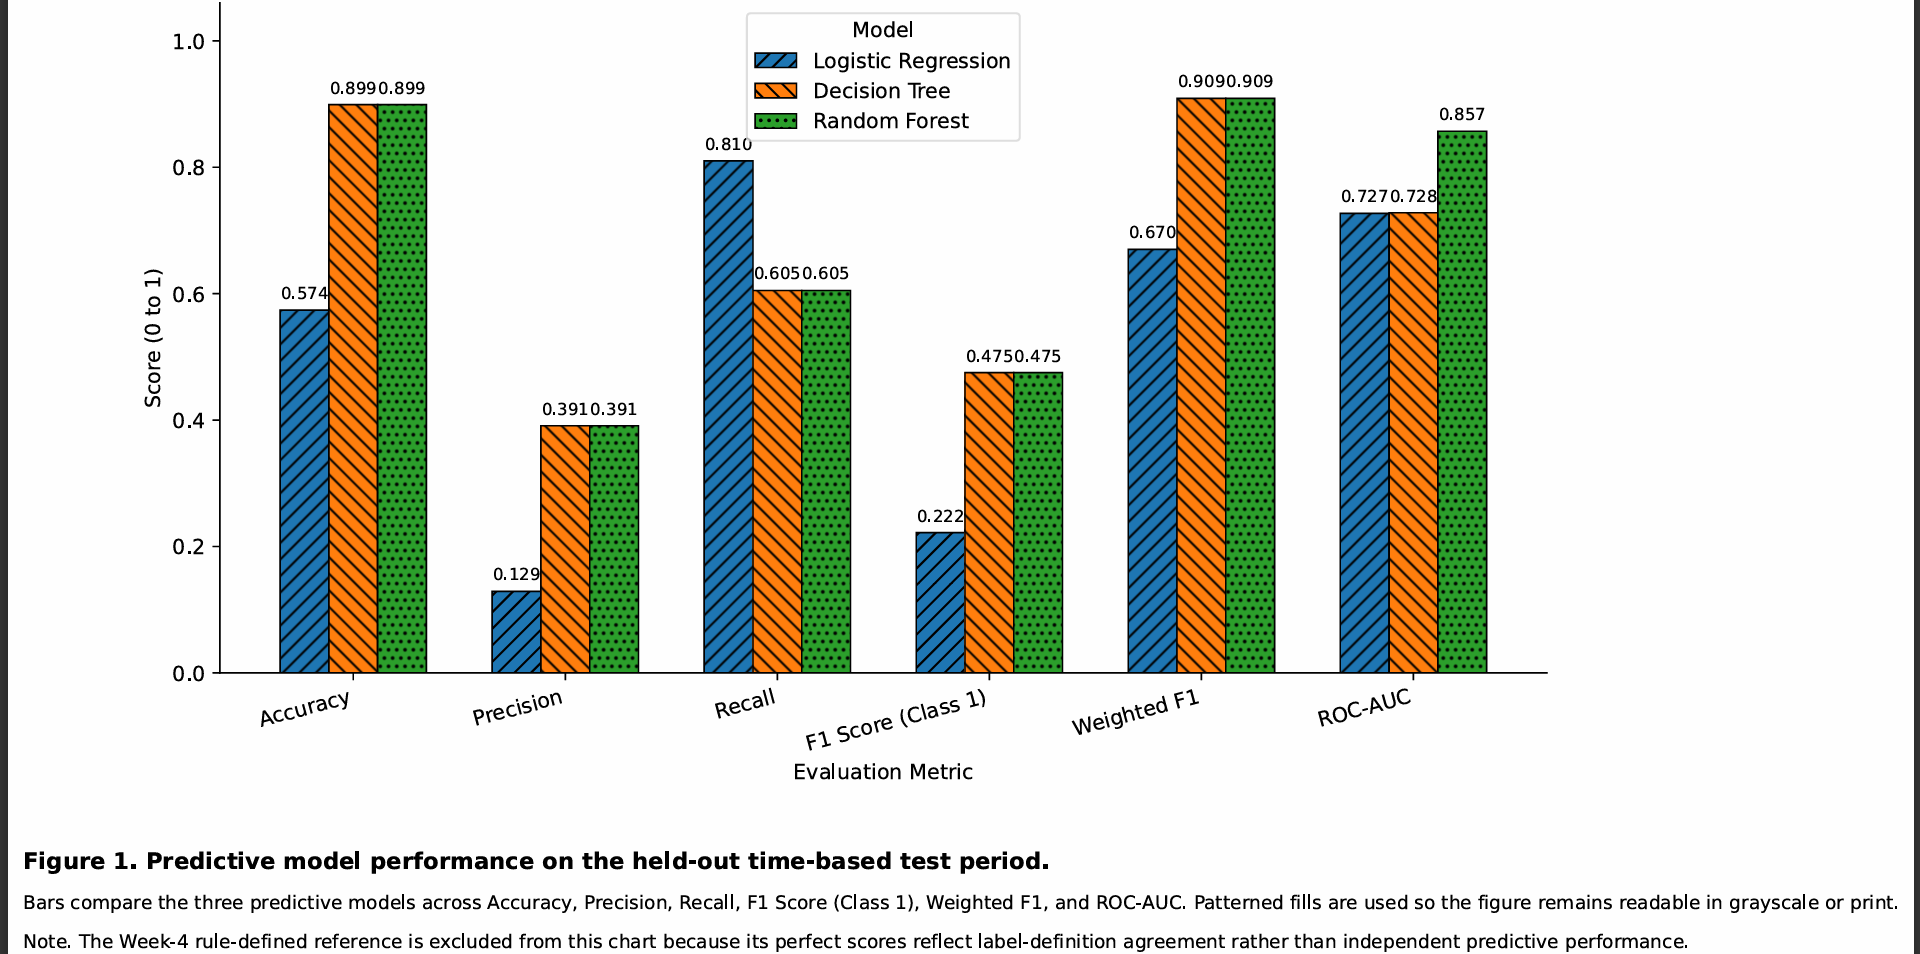

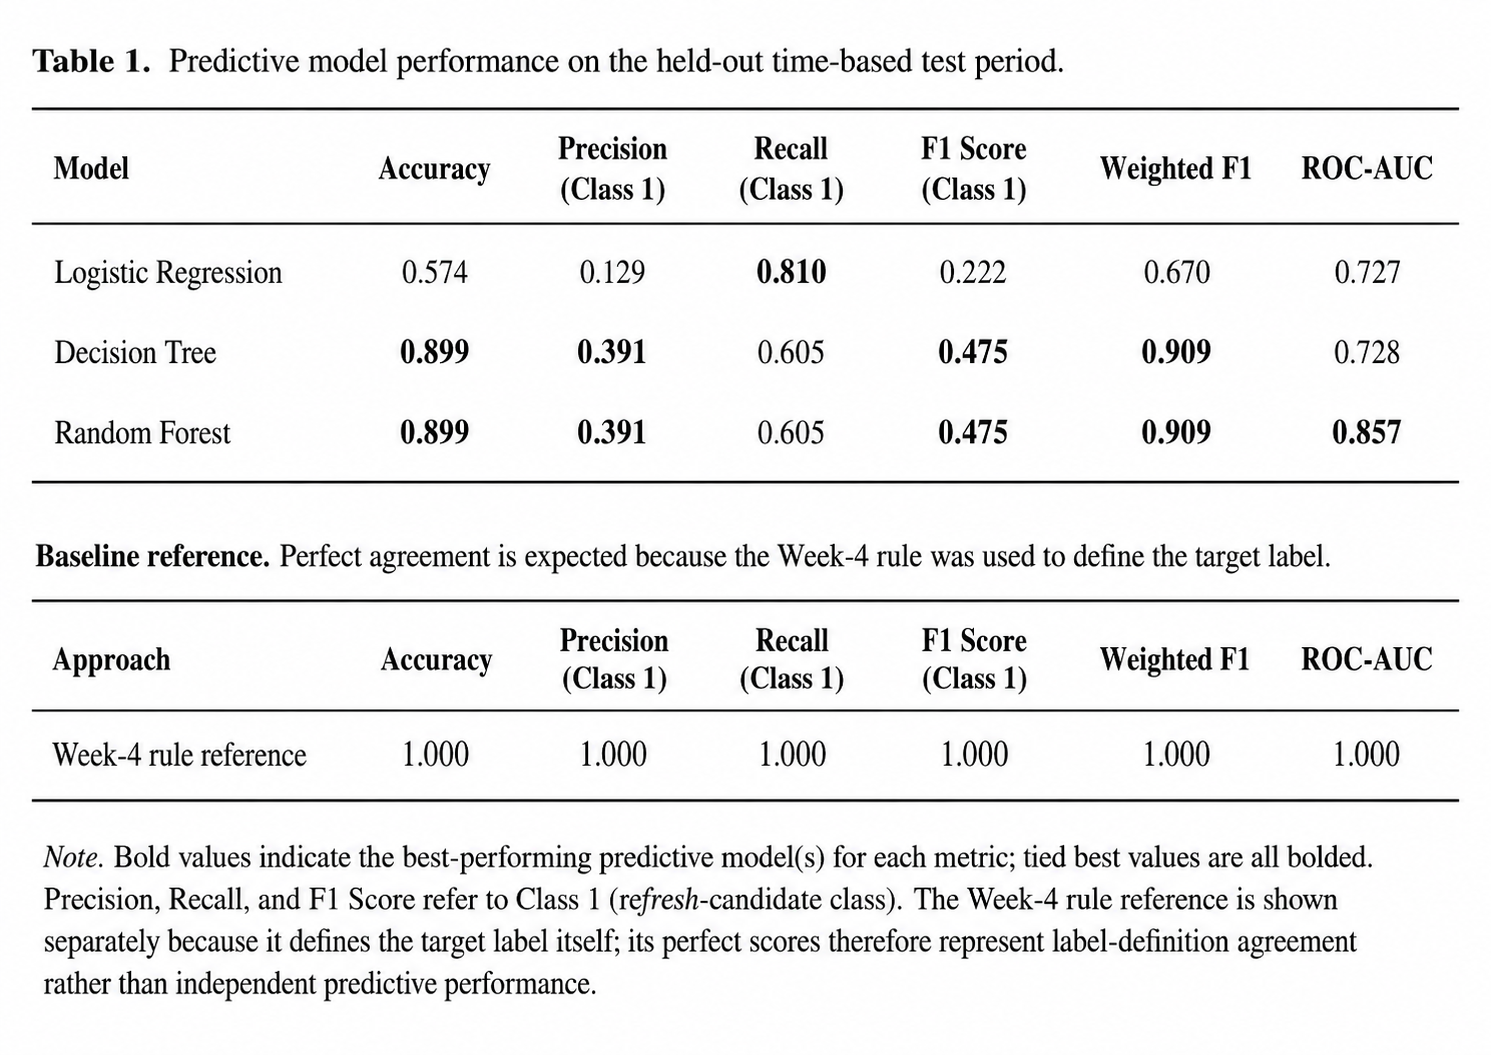

**Permutation importance**:

To understand “what does the model mostly lean on” I use permutation importance technique to identify which features are most important for our model’s predictions by measuring how much the model's performance drops when a feature's values are randomly shuffled (permuted).
The following figure shows the top features by permutation importance that clearly indicates which feature model mostly rely on to give prediciton


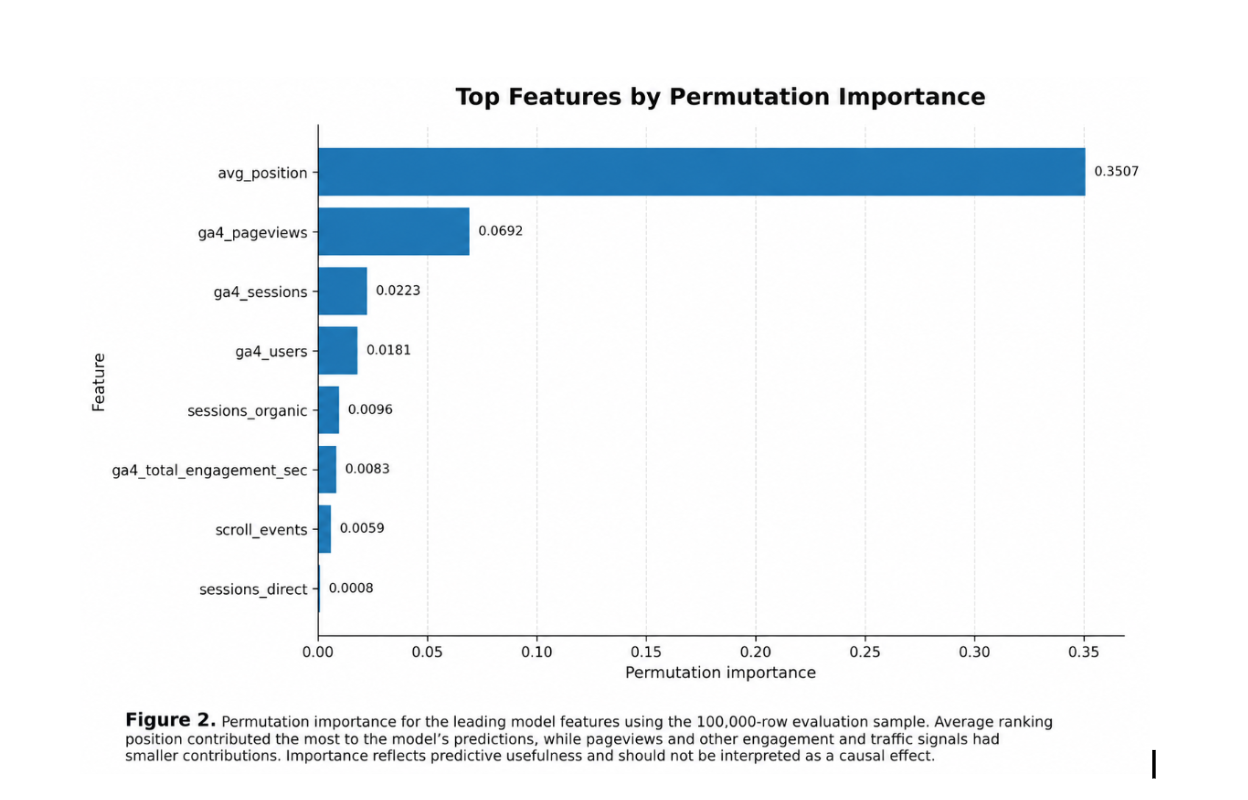

**Error Analysis**:
After doing analysis on the errors of the model to understand where the model is giving wrong predictions I find out the total number of False positives of **12724** and number of False Negatives of **5064**. It means that mostly the model is giving the wrong prediction that the page needs a refresh




**Final Rule Comparison:**

As a final validation step, the Previous Global CTR Rule was compared with the FlyRank Position-Tier Rule across 15 model-metric comparisons using Logistic Regression, Decision Tree, and Random Forest. The Previous Global CTR Rule performed better in 12 comparisons, while the Position-Tier Rule performed better in 3 as shown in figure 2.



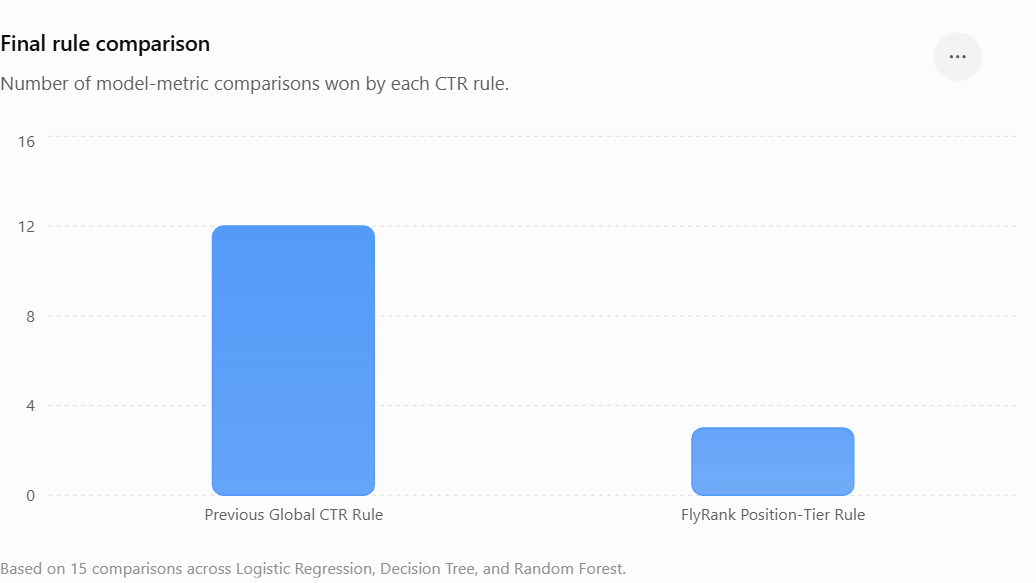

**Notebook link:** [**View Notebook**](https://github.com/abdullahnaeem151015-lgtm/Machine-learning-content-refresh-study/blob/main/work/notebooks/Copy_of_w06_validation_audit%20(2).ipynb)

## 5. Limitations

*What this work cannot claim.*

# **Limitations:**

This research helps identify content that could be a potential candidate for refresh, but it does not guarantee that a flagged page definitely requires an update.

The target is constructed from percentile-based CTR and impression thresholds, so it represents a practical proxy rather than independently verified ground truth. The study also does not claim to determine the reason why a page has low CTR or why it may require a refresh.

Low CTR may be influenced by several factors, including ranking position, search intent, seasonality, content type, SERP competition, temporary traffic changes, or other conditions not fully represented by the available features.

Rows with missing selected model features were excluded before training and evaluation. This may reduce representativeness for content with incomplete analytics data.

Evaluation was conducted on a 30% stratified sample using a single time-based holdout period. Model performance has therefore not yet been demonstrated across multiple months, different seasonal conditions, or future data distributions.

Class imbalance also remains relevant. Although SMOTE was applied to the training data, precision for the refresh class remained moderate. Model outputs should therefore be used to prioritize manual review rather than automatically trigger content refreshes.

The underlying modeling table contains daily content-performance observations, while the practical business decision is ultimately made at content or page level. The final recommendation queue therefore removes repeated content IDs for presentation, but further work could aggregate performance directly at page level before target construction and modeling.

Finally, this is an observational classification system. It does not establish that refreshing a flagged page will cause CTR, traffic, rankings, or other search-performance metrics to improve. Demonstrating that would require post-refresh outcome data, controlled experiments, or independently verified human review labels.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

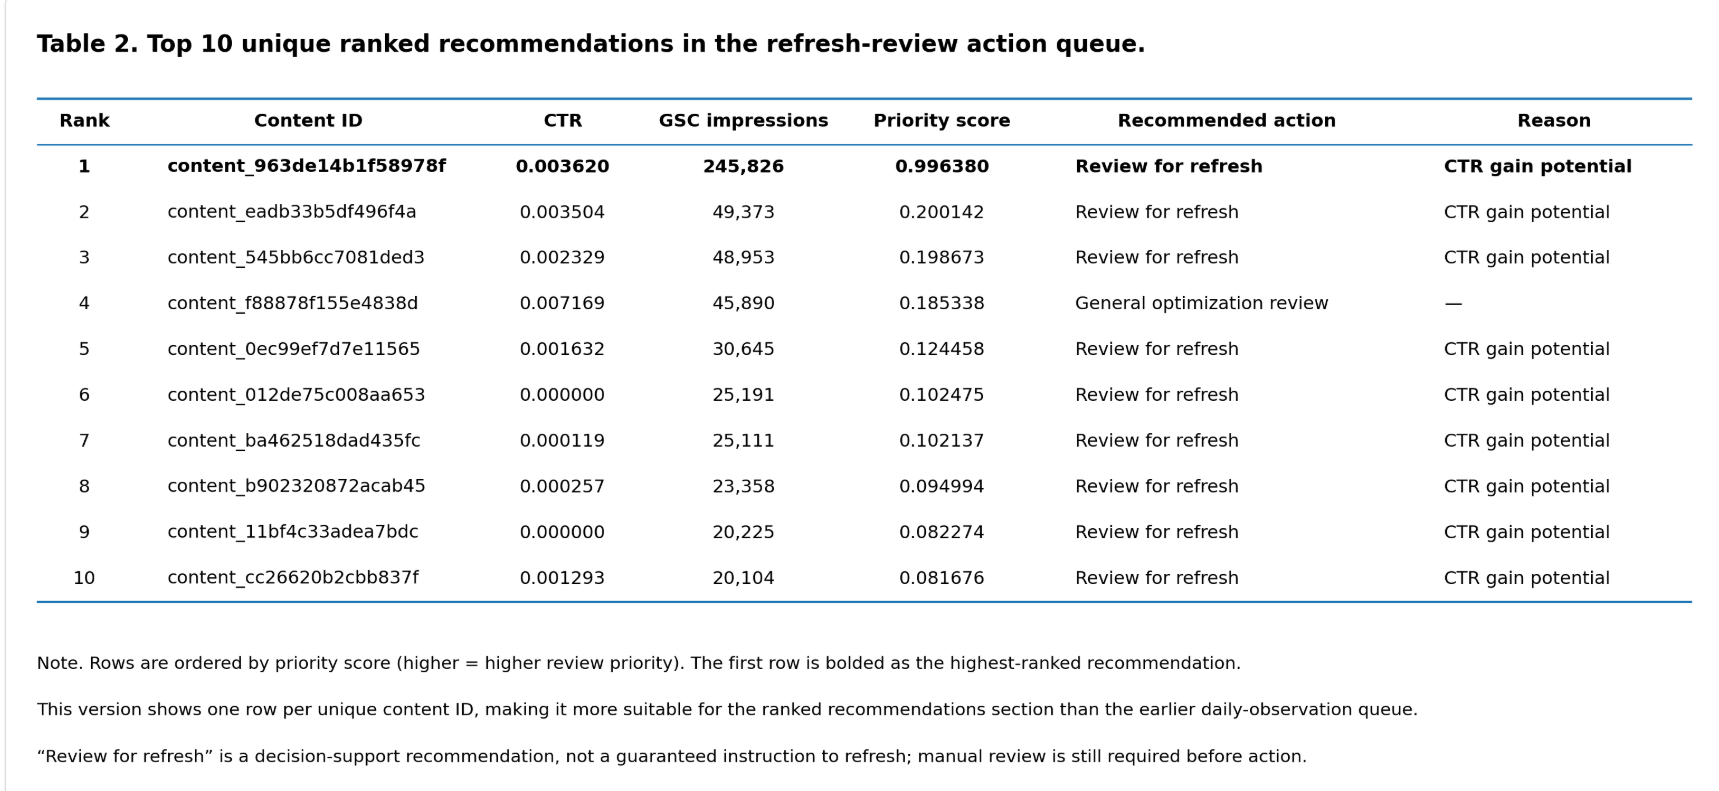

# **Reproducibility**

The analysis and model-development workflow are available in the linked notebooks below. These notebooks contain the preprocessing, target construction, model training, validation, permutation importance, error analysis, ranked recommendation logic, and supporting experiments used to produce the results presented in this paper.

**Week 4 — Baseline & Refresh Rule**

Defines the refresh-candidate rule and baseline scoring logic.

[**View Notebook**](https://github.com/abdullahnaeem151015-lgtm/Machine-learning-content-refresh-study/blob/main/work/notebooks/Copy_of_w04_baseline_score%20(1).ipynb)

**Week 5 — Model Development & Evaluation**

Contains Logistic Regression, Decision Tree, Random Forest, time-aware validation, SMOTE, permutation importance, and error analysis.

[**View Notebook**](https://github.com/abdullahnaeem151015-lgtm/Machine-learning-content-refresh-study/blob/main/work/notebooks/w05_model.ipynb)

**Week 6 — Validation & Rule Audit**

Contains leakage checks and comparison of the original global CTR rule with the position-aware alternative.

[**View Notebook**](https://github.com/abdullahnaeem151015-lgtm/Machine-learning-content-refresh-study/blob/main/work/notebooks/Copy_of_w06_validation_audit%20(2).ipynb)

**Week 7 — Ranked Recommendations / Action Playbook**

Contains priority scoring, action assignment, and generation of the ranked refresh-review queue.

[**View Notebook**](https://github.com/abdullahnaeem151015-lgtm/Machine-learning-content-refresh-study/blob/main/work/notebooks/Copy_of_w07_action_playbook%20(1).ipynb)

**GitHub Repository**

Complete project code, notebooks, outputs, and supporting files.

[**View Repository**](https://github.com/abdullahnaeem151015-lgtm/Machine-learning-content-refresh-study/tree/main)

# **Acknowledgments & Data Credit**

This project was completed as part of the FlyRank ML Internship.

The analysis was built on the FlyRank ML Internship dataset, including pseudonymized Google Search Console and Google Analytics performance data used for research and model development.

The author acknowledges FlyRank for providing the dataset, project framework, and internship environment that supported this study.

**Data credit:** Built on the FlyRank ML Internship dataset  https://flyrank.ai


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
